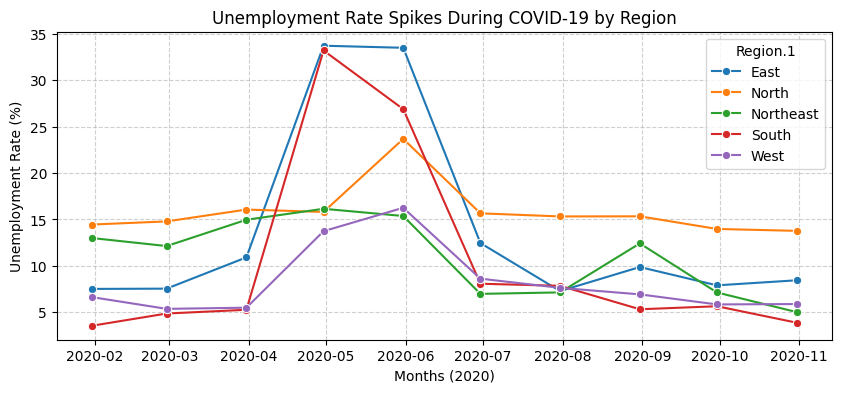

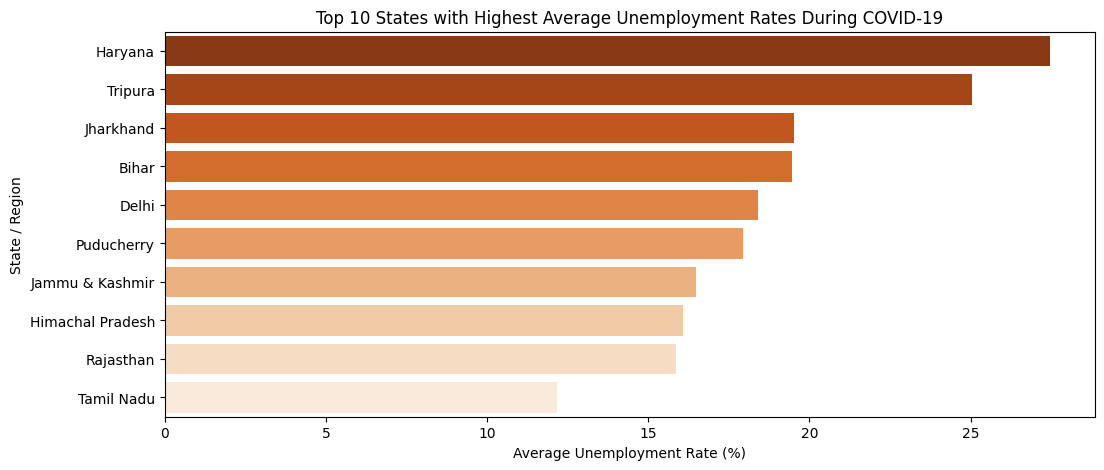

C:\Users\DELL\AppData\Local\Temp\ipykernel_12568\1496275190.py:48: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=False, errors='coerce')


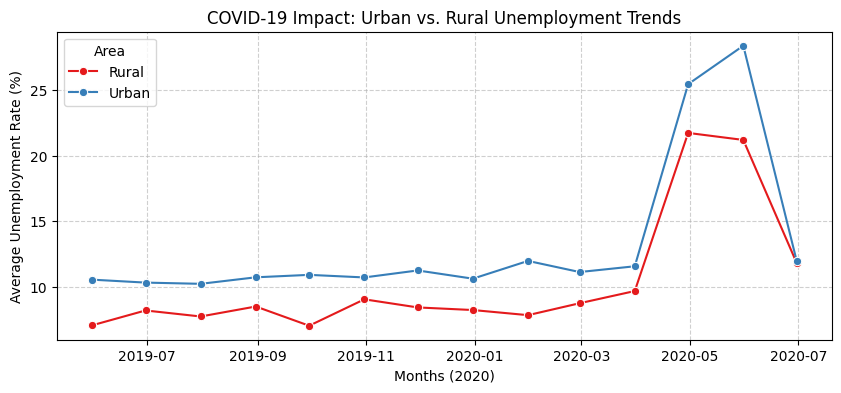

In [13]:
# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# FILE 1 ANALYSIS: Regional Breakdown (Rates File)
# =========================================================
file_1 = r"C:\Users\DELL\Downloads\Oasis_Infobyte_Projects\Unemployment_Rate_upto_11_2020[1].csv"

df1 = pd.read_csv(file_1)
df1.columns = df1.columns.str.strip()
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)

# Process data for the first two charts
state_data = df1.groupby("Region")["Estimated Unemployment Rate (%)"].mean().reset_index()
state_data = state_data.sort_values(by="Estimated Unemployment Rate (%)", ascending=False)
monthly_trend = df1.groupby(["Date", "Region.1"])["Estimated Unemployment Rate (%)"].mean().reset_index()

# CHART 1: Timeline Spikes by Region
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_trend, x="Date", y="Estimated Unemployment Rate (%)", hue="Region.1", marker="o")
plt.title("Unemployment Rate Spikes During COVID-19 by Region")
plt.xlabel("Months (2020)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# CHART 2: Hardest Hit States Ranked
plt.figure(figsize=(12, 5))
sns.barplot(x="Estimated Unemployment Rate (%)", y="Region", hue="Region", data=state_data.head(10), palette="Oranges_r", legend=False)
plt.title("Top 10 States with Highest Average Unemployment Rates During COVID-19")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State / Region")
plt.show()


# =========================================================
# FILE 2 ANALYSIS: Urban vs Rural Sectors (India File)
# =========================================================
# Using your exact verified file path
file_2 = r"C:\Users\DELL\Downloads\Oasis_Infobyte_Projects\Unemployment_in_India[1].csv"

df2 = pd.read_csv(file_2)
df2.columns = df2.columns.str.strip()

# Clean up dates and drop missing rows
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=False, errors='coerce')
df2 = df2.dropna()

urban_rural_trend = df2.groupby(["Date", "Area"])["Estimated Unemployment Rate (%)"].mean().reset_index()

# CHART 3: Urban vs Rural Sectors
plt.figure(figsize=(10, 4))
sns.lineplot(data=urban_rural_trend, x="Date", y="Estimated Unemployment Rate (%)", hue="Area", marker="o", palette="Set1")
plt.title("COVID-19 Impact: Urban vs. Rural Unemployment Trends")
plt.xlabel("Months (2020)")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()